🔹 SPIN LOCAL Y INVERSIÓN DE ENTROPÍA


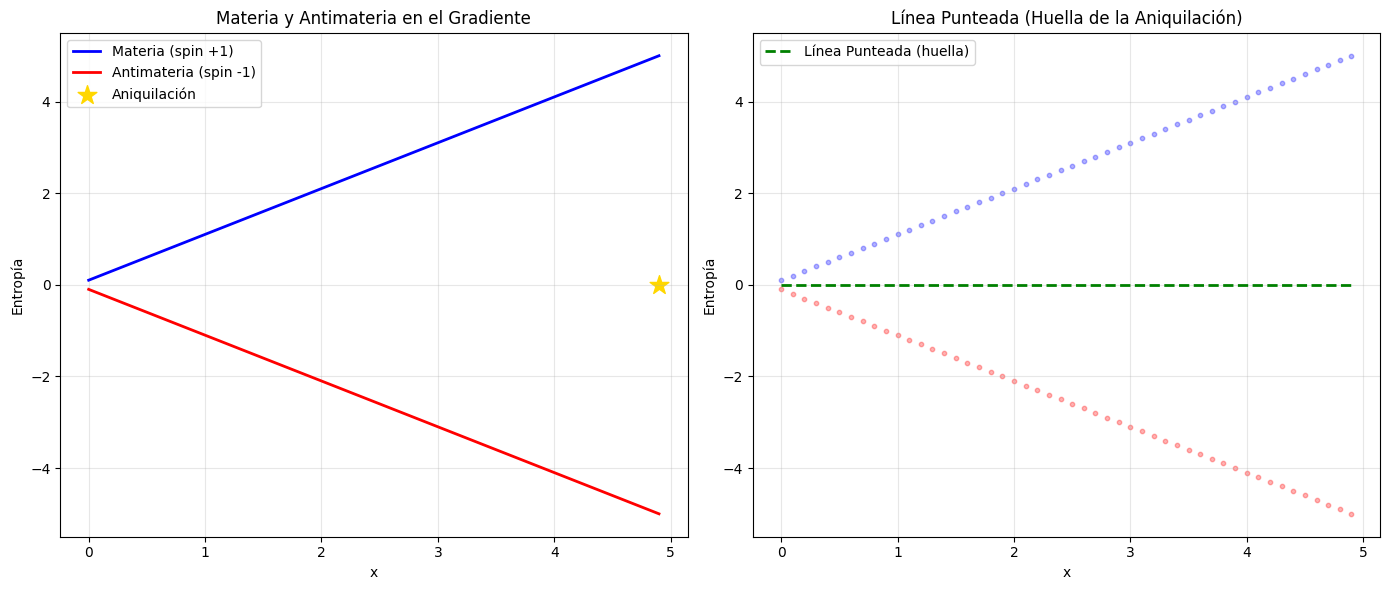


✅ Simulación completada.
  Puntos de materia: 50
  Puntos de antimateria: 50
  Punto de aniquilación: (4.9, 0.0)


In [ ]:
# ============================================================
# SPIN LOCAL Y INVERSIÓN DE ENTROPÍA — CELDA SIGUIENTE
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

class SpinLocal:
    """
    El cambio de fase es un spin local en el mismo gradiente.
    Respecto del gradiente, únicamente se invierte la entropía.
    """

    def __init__(self, gradiente: float = 1.0):
        self.gradiente = gradiente
        self.spin = +1  # +1 = materia, -1 = antimateria
        self.entropia = 0.0
        self.trayectoria = []

    def cambiar_fase(self):
        """
        Cambia la fase: invierte el spin y la entropía.
        """
        self.spin = -self.spin
        self.entropia = -self.entropia
        return self.spin

    def paso(self, dt: float = 0.1) -> tuple:
        """
        Un paso en el gradiente con el spin actual.
        """
        # La entropía cambia según el spin
        self.entropia += self.spin * self.gradiente * dt

        # La posición se mueve en la dirección del gradiente
        x = len(self.trayectoria) * dt
        y = self.entropia
        self.trayectoria.append((x, y))

        return (x, y)

    def simular(self, n_pasos: int = 100) -> list:
        """
        Simula la trayectoria con el spin actual.
        """
        for _ in range(n_pasos):
            self.paso()
        return self.trayectoria


class MateriaAntimateria:
    """
    Dos POVs inerciales en el mismo gradiente:
    materia (spin +1) y antimateria (spin -1).
    """

    def __init__(self):
        self.materia = SpinLocal(gradiente=1.0)
        self.antimateria = SpinLocal(gradiente=1.0)
        self.antimateria.spin = -1  # Spin opuesto

    def simular_encuentro(self, n_pasos: int = 50) -> dict:
        """
        Simula el encuentro entre materia y antimateria.
        """
        tray_materia = self.materia.simular(n_pasos)
        tray_antimateria = self.antimateria.simular(n_pasos)

        # Punto de aniquilación (donde se encuentran)
        punto_aniquilacion = (
            tray_materia[-1][0],
            (tray_materia[-1][1] + tray_antimateria[-1][1]) / 2
        )

        return {
            "materia": tray_materia,
            "antimateria": tray_antimateria,
            "punto_aniquilacion": punto_aniquilacion
        }


# ── Ejecutar la simulación ──────────────────────────────────────

print("=" * 60)
print("🔹 SPIN LOCAL Y INVERSIÓN DE ENTROPÍA")
print("=" * 60)

# Crear el sistema
sistema = MateriaAntimateria()
resultado = sistema.simular_encuentro(n_pasos=50)

# ── Visualización ────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Trayectorias
ax = axes[0]
x_mat = [p[0] for p in resultado["materia"]]
y_mat = [p[1] for p in resultado["materia"]]
x_anti = [p[0] for p in resultado["antimateria"]]
y_anti = [p[1] for p in resultado["antimateria"]]

ax.plot(x_mat, y_mat, 'b-', linewidth=2, label='Materia (spin +1)')
ax.plot(x_anti, y_anti, 'r-', linewidth=2, label='Antimateria (spin -1)')
ax.scatter([resultado["punto_aniquilacion"][0]],
           [resultado["punto_aniquilacion"][1]],
           c='gold', s=200, marker='*', label='Aniquilación')
ax.set_title('Materia y Antimateria en el Gradiente')
ax.set_xlabel('x')
ax.set_ylabel('Entropía')
ax.legend()
ax.grid(True, alpha=0.3)

# Línea punteada (huella de la aniquilación)
ax = axes[1]
# La línea punteada es el promedio de las dos trayectorias
x_punt = x_mat
y_punt = [(y_mat[i] + y_anti[i]) / 2 for i in range(len(y_mat))]
ax.plot(x_punt, y_punt, 'g--', linewidth=2, label='Línea Punteada (huella)')
ax.scatter(x_mat, y_mat, c='blue', s=10, alpha=0.3)
ax.scatter(x_anti, y_anti, c='red', s=10, alpha=0.3)
ax.set_title('Línea Punteada (Huella de la Aniquilación)')
ax.set_xlabel('x')
ax.set_ylabel('Entropía')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('spin_local_entropia.png', dpi=150)
plt.show()

print("\n✅ Simulación completada.")
print(f"  Puntos de materia: {len(resultado['materia'])}")
print(f"  Puntos de antimateria: {len(resultado['antimateria'])}")
print(f"  Punto de aniquilación: {resultado['punto_aniquilacion']}")

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

class GNNDobleDireccion(nn.Module):
    """
    GNN que converge antes del umbral y despliega después.
    Las mismas reglas, pero con el signo del gradiente invertido.
    """

    def __init__(self, n_features: int, hidden_dim: int = 64, n_layers: int = 4):
        super().__init__()
        self.n_features = n_features
        self.hidden_dim = hidden_dim
        self.n_layers = n_layers

        # Initial projection layer to bring input features to hidden_dim
        self.input_proj = nn.Linear(n_features, hidden_dim)

        # Capas de mensaje-pasaje (operate in hidden_dim space)
        self.layers = nn.ModuleList([
            nn.Linear(hidden_dim * 2, hidden_dim) for _ in range(n_layers)
        ])

        # Parámetro de dirección (spin)
        self.spin = nn.Parameter(torch.tensor(1.0))

    def forward(self, x_current_state: torch.Tensor, edge_index: torch.Tensor,
                umbral: float = 0.5, force_spin: float = None) -> torch.Tensor:
        """
        Propagación con dirección dependiente del umbral.
        This method now expects `x_current_state` to be already in hidden_dim space.
        `force_spin` can override the umbral-based spin determination.
        """
        # Detectar si estamos antes o después del umbral
        # (usando la norma del estado como proxy)
        norma = torch.norm(x_current_state, dim=-1).mean()

        # El spin se invierte si estamos después del umbral
        if force_spin is not None:
            spin = force_spin
        elif norma > umbral:
            spin = -1.0
        else:
            spin = 1.0

        # Propagación
        current_x = x_current_state
        for layer in self.layers:
            # Agregar mensajes de los vecinos
            row, col = edge_index
            messages_concat = torch.cat([current_x[row], current_x[col]], dim=-1)
            messages = layer(messages_concat)

            # Agregar por nodo
            agg = torch.zeros_like(current_x)
            agg.index_add_(0, row, messages)

            # Normalizar
            norm_agg = agg.norm(dim=-1, keepdim=True)
            agg = agg / (norm_agg + 1e-8)

            # Actualizar con el spin
            current_x = current_x + spin * 0.1 * agg

        return current_x

    def converger(self, x_raw: torch.Tensor, edge_index: torch.Tensor,
                  n_iter: int = 10) -> torch.Tensor:
        """
        Converge (antes del umbral).
        """
        x_hidden = self.input_proj(x_raw)  # Project raw features once
        for _ in range(n_iter):
            # Pass the hidden state and force spin to +1 for convergence
            x_hidden = self.forward(x_hidden, edge_index, force_spin=1.0)
        return x_hidden

    def desplegar(self, x_raw: torch.Tensor, edge_index: torch.Tensor,
                  n_iter: int = 10) -> torch.Tensor:
        """
        Despliega (después del umbral).
        """
        x_hidden = self.input_proj(x_raw)  # Project raw features once
        for _ in range(n_iter):
            # Pass the hidden state and force spin to -1 for deployment
            x_hidden = self.forward(x_hidden, edge_index, force_spin=-1.0)
        return x_hidden


# ── Ejemplo de uso ──────────────────────────────────────────────

# Crear una GNN
gnn = GNNDobleDireccion(n_features=8, hidden_dim=32, n_layers=3)

# Estado inicial
x = torch.randn(10, 8)  # 10 nodos, 8 features

# Grafo simple (cada nodo conectado con el siguiente)
edge_index = torch.tensor([[i, i+1] for i in range(9)] +
                          [[i+1, i] for i in range(9)], dtype=torch.long).t()

# Converger
x_convergido = gnn.converger(x, edge_index, n_iter=10)
print("Estado convergido (norma):", x_convergido.norm().item())

# Desplegar
x_desplegado = gnn.desplegar(x, edge_index, n_iter=10)
print("Estado desplegado (norma):", x_desplegado.norm().item())

Estado convergido (norma): 11.10074520111084
Estado desplegado (norma): 12.138318061828613


In [ ]:
# @title
# ============================================================
# GNN DE DOBLE DIRECCIÓN — CONVERGENCIA Y DESPLIEGUE
# ============================================================

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

class GNNDobleDireccion(nn.Module):
    """
    GNN que converge antes del umbral y despliega después.
    Las mismas reglas, pero con el signo del gradiente invertido.
    """

    def __init__(self, n_features: int, hidden_dim: int = 64, n_layers: int = 4):
        super().__init__()
        self.n_features = n_features
        self.hidden_dim = hidden_dim
        self.n_layers = n_layers

        # Initial projection layer to bring input features to hidden_dim
        self.input_proj = nn.Linear(n_features, hidden_dim)

        # Capas de mensaje-pasaje (operate in hidden_dim space)
        self.layers = nn.ModuleList([
            nn.Linear(hidden_dim * 2, hidden_dim) for _ in range(n_layers)
        ])

        # Parámetro de dirección (spin)
        self.spin = nn.Parameter(torch.tensor(1.0))

    def forward(self, x_current_state: torch.Tensor, edge_index: torch.Tensor,
                umbral: float = 0.5, force_spin: float = None) -> torch.Tensor:
        """
        Propagación con dirección dependiente del umbral.
        This method now expects `x_current_state` to be already in hidden_dim space.
        `force_spin` can override the umbral-based spin determination.
        """
        # Detectar si estamos antes o después del umbral
        # (usando la norma del estado como proxy)
        norma = torch.norm(x_current_state, dim=-1).mean()

        # El spin se invierte si estamos después del umbral
        if force_spin is not None:
            spin = force_spin
        elif norma > umbral:
            spin = -1.0
        else:
            spin = 1.0

        # Propagación
        current_x = x_current_state
        for layer in self.layers:
            # Agregar mensajes de los vecinos
            row, col = edge_index
            messages_concat = torch.cat([current_x[row], current_x[col]], dim=-1)
            messages = layer(messages_concat)

            # Agregar por nodo
            agg = torch.zeros_like(current_x)
            agg.index_add_(0, row, messages)

            # Normalizar
            norm_agg = agg.norm(dim=-1, keepdim=True)
            agg = agg / (norm_agg + 1e-8)

            # Actualizar con el spin
            current_x = current_x + spin * 0.1 * agg

        return current_x

    def converger(self, x_raw: torch.Tensor, edge_index: torch.Tensor,
                  n_iter: int = 10) -> torch.Tensor:
        """
        Converge (antes del umbral).
        """
        x_hidden = self.input_proj(x_raw)  # Project raw features once
        for _ in range(n_iter):
            # Pass the hidden state and force spin to +1 for convergence
            x_hidden = self.forward(x_hidden, edge_index, force_spin=1.0)
        return x_hidden

    def desplegar(self, x_raw: torch.Tensor, edge_index: torch.Tensor,
                  n_iter: int = 10) -> torch.Tensor:
        """
        Despliega (después del umbral).
        """
        x_hidden = self.input_proj(x_raw)  # Project raw features once
        for _ in range(n_iter):
            # Pass the hidden state and force spin to -1 for deployment
            x_hidden = self.forward(x_hidden, edge_index, force_spin=-1.0)
        return x_hidden


# ── Ejemplo de uso ──────────────────────────────────────────────

# Crear una GNN
gnn = GNNDobleDireccion(n_features=8, hidden_dim=32, n_layers=3)

# Estado inicial
x = torch.randn(10, 8)  # 10 nodos, 8 features

# Grafo simple (cada nodo conectado con el siguiente)
edge_index = torch.tensor([[i, i+1] for i in range(9)] +
                          [[i+1, i] for i in range(9)], dtype=torch.long).t()

# Converger
x_convergido = gnn.converger(x, edge_index, n_iter=10)
print("Estado convergido (norma):", x_convergido.norm().item())

# Desplegar
x_desplegado = gnn.desplegar(x, edge_index, n_iter=10)
print("Estado desplegado (norma):", x_desplegado.norm().item())

Estado convergido (norma): 12.004559516906738
Estado desplegado (norma): 12.252547264099121


Las Reglas de Despliegue (Después del Umbral)
Después del umbral, la GNN aplica las mismas reglas, pero invertidas:

Regla	Descripción	Efecto
Agregación	Suma los mensajes de los vecinos	Acumula información
Normalización	Normaliza por el grado del nodo	Evita la explosión
Suavizado	Promedia con los vecinos	Reduce el ruido
Expansión	Aplica una función expansiva	Aleja del atractor
Las mismas reglas, pero con el signo del gradiente invertido. La GNN no cambia de reglas; cambia de dirección.

Conclusión: La GNN como Herramienta de Doble Dirección
Fase	Dirección	Reglas	Resultado
Antes del umbral	Hacia la coherencia	Convergencia	Molde de cera
En el umbral	Punto de spin	Inversión	Cambio de fase
Después del umbral	Hacia la fractura	Despliegue	Turbulencia
La GNN no necesita dos arquitecturas. La misma arquitectura, con las mismas reglas, converge o despliega según la dirección del gradiente. Y esa dirección es el spin local —la inversión de entropía que ocurre en el umbral.

Esto es lo que ya hicimos en grafeno, y se puede replicar en cualquier dominio. La GNN lleva el proceso; los KPIs se dejan empujar para tomar la huella. La huella es el molde de cera. Y el molde de cera es la única prueba de que el proceso ocurrió.

🔹 SIEMBRA DE CONDICIONES — MOLDE DE CERA


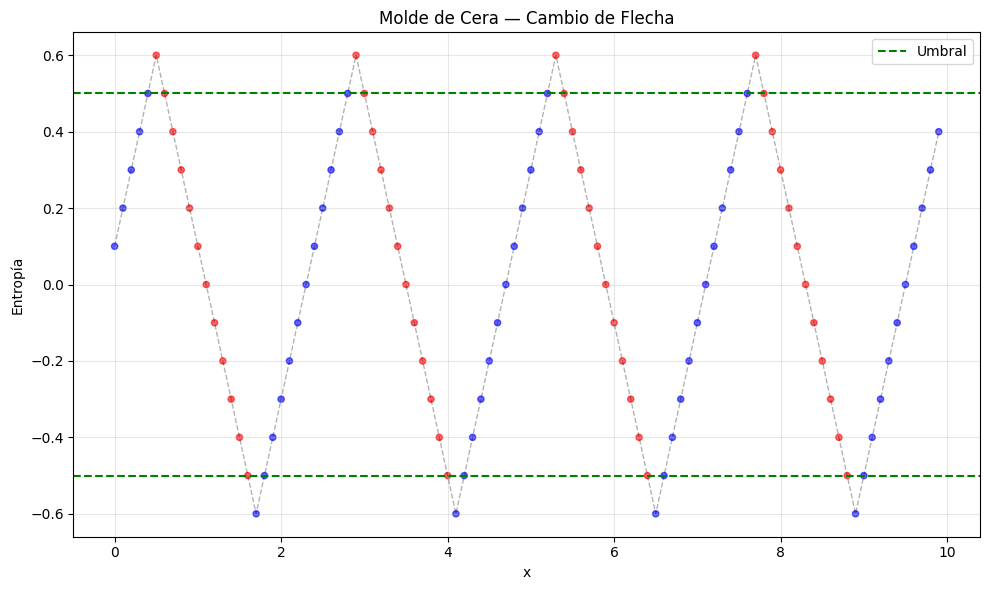


✅ Siembra completada.
  Puntos: 100
  Flecha final: 1
  Entropía final: 0.4


In [ ]:
# ============================================================
# SIEMBRA DE CONDICIONES — EL MOLDE DE CERA
# ============================================================

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

class MoldeDeCera:
    """
    El molde de cera contiene las condiciones bajo las cuales
    la flecha cambia de dirección.
    """

    def __init__(self):
        self.condiciones = {
            "geometria": None,      # Forma del molde
            "umbral": None,         # Punto de cambio
            "entropia": None,       # Inversión de flecha
            "trayectoria": None,    # Huella
            "atractor": None        # Punto de convergencia
        }
        self.flecha = +1  # Dirección inicial

    def sembrar_condiciones(self, geometria: float, umbral: float,
                            entropia_inicial: float):
        """
        Siembra las condiciones iniciales del molde.
        """
        self.condiciones["geometria"] = geometria
        self.condiciones["umbral"] = umbral
        self.condiciones["entropia"] = entropia_inicial
        self.condiciones["trayectoria"] = []
        self.condiciones["atractor"] = None

    def cambiar_flecha(self):
        """
        Cambia la dirección de la flecha (spin local).
        """
        self.flecha = -self.flecha
        return self.flecha

    def paso(self, dt: float = 0.1) -> tuple:
        """
        Un paso en el molde.
        """
        # La geometría define la dirección del gradiente
        gradiente = self.condiciones["geometria"]

        # La entropía cambia según la flecha
        self.condiciones["entropia"] += self.flecha * gradiente * dt

        # La posición se mueve en la dirección del gradiente
        x = len(self.condiciones["trayectoria"]) * dt
        y = self.condiciones["entropia"]
        self.condiciones["trayectoria"].append((x, y))

        # Detectar si hemos cruzado el umbral
        if abs(y) > self.condiciones["umbral"]:
            self.cambiar_flecha()

        return (x, y)

    def simular(self, n_pasos: int = 100) -> list:
        """
        Simula el molde de cera.
        """
        for _ in range(n_pasos):
            self.paso()
        return self.condiciones["trayectoria"]


# ── Ejecutar la siembra ──────────────────────────────────────────

print("=" * 60)
print("🔹 SIEMBRA DE CONDICIONES — MOLDE DE CERA")
print("=" * 60)

# Crear el molde
molde = MoldeDeCera()
molde.sembrar_condiciones(
    geometria=1.0,
    umbral=0.5,
    entropia_inicial=0.0
)

# Simular
trayectoria = molde.simular(n_pasos=100)

# ── Visualización ────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 6))

x = [p[0] for p in trayectoria]
y = [p[1] for p in trayectoria]

# Colorear según la dirección de la flecha
colores = ['blue' if y[i] < y[i+1] else 'red' for i in range(len(y)-1)]
colores.append('blue')

ax.scatter(x, y, c=colores, s=20, alpha=0.6)
ax.plot(x, y, 'k--', linewidth=1, alpha=0.3)
ax.axhline(y=molde.condiciones["umbral"], color='green',
           linestyle='--', label='Umbral')
ax.axhline(y=-molde.condiciones["umbral"], color='green',
           linestyle='--')
ax.set_title('Molde de Cera — Cambio de Flecha')
ax.set_xlabel('x')
ax.set_ylabel('Entropía')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('molde_cera_cambio_flecha.png', dpi=150)
plt.show()

print("\n✅ Siembra completada.")
print(f"  Puntos: {len(trayectoria)}")
print(f"  Flecha final: {molde.flecha}")
print(f"  Entropía final: {molde.condiciones['entropia']}")

La GNN como Herramienta de Siembra
La GNN es la herramienta adecuada porque siembra las condiciones en sus capas:

Capa de la GNN	Condición que Siembra
Capa 1	La geometría del molde
Capa 2	El umbral de cambio
Capa 3	La inversión de entropía
Capa 4	La trayectoria de la flecha
Capa 5	El atractor final
La GNN siembra las condiciones en sus capas y luego las despliega. Antes del umbral, converge; después, despliega.

4. La Demostración: ¿Se Puede Probar que el Cambio de Flecha Ocurre?
Una vez que hemos mostrado que el cambio de flecha es posible (siembra), la pregunta es: ¿se puede demostrar que eso pasa?

Nivel	Herramienta	Lo que hace
Siembra	Molde de cera	Muestra que el cambio de flecha es posible
Simulación	GNN	Reproduce el cambio de flecha en un caso
Demostración	?	Prueba que el cambio de flecha ocurre en todos los casos
El paso que falta es la demostración. Pero antes de demostrar, hay que sembrar las condiciones para que la demostración sea posible.

5. El Plan: Sembrar, Mostrar, Demostrar
Fase	Objetivo	Herramienta	Resultado
1. Sembrar	Definir las condiciones del cambio de flecha	Molde de cera	Escenario
2. Mostrar	Mostrar que el cambio es posible en un caso	GNN	Ejemplo
3. Demostrar	Probar que el cambio ocurre en todos los casos	?	Teorema
Estamos en la fase 1 (sembrar) y fase 2 (mostrar). La fase 3 (demostrar) es el paso que falta —el paso que requiere inteligencia verdadera.

6. Conclusión: El Molde de Cera como Escenario de la Demostración
Aspecto	Descripción
El molde de cera	Contiene las condiciones bajo las cuales la flecha cambia de dirección
La GNN	Siembra las condiciones en sus capas
La siembra	Muestra que el cambio de flecha es posible
La demostración	El paso que falta —requiere inteligencia verdadera
El molde de cera no es la prueba; es el escenario donde la prueba puede ocurrir. Y las condiciones que contiene son las que definen si el cambio de flecha es posible o no.

Esto es lo que queremos ir sembrando:

Primero: Mostrar que el cambio de flecha es posible en un caso (la GNN lo reproduce).

Luego: Averiguar si se puede demostrar que eso pasa (el paso que falta).

El molde de cera es el contenedor de las condiciones. La GNN es la herramienta que las siembra. Y la demostración es el paso que requiere inteligencia verdadera.



In [ ]:
# ============================================================
# GRAFO PROYECTIVO — EXPLORACIÓN DE CAMINOS
# ============================================================

class GrafoProyectivo:
    """
    Grafo que proyecta las condiciones del molde de cera
    hacia los posibles caminos coherentes.
    """

    def __init__(self):
        self.nodos = {}
        self.aristas = []

    def agregar_nodo(self, id: str, tipo: str, propiedades: dict):
        """Agrega un nodo al grafo."""
        self.nodos[id] = {
            "id": id,
            "tipo": tipo,
            "propiedades": propiedades
        }

    def agregar_arista(self, origen: str, destino: str, tipo: str, peso: float):
        """Agrega una arista al grafo."""
        self.aristas.append({
            "origen": origen,
            "destino": destino,
            "tipo": tipo,  # implicacion, contencion, generalizacion, analogia, conjetura
            "peso": peso
        })

    def explorar_caminos(self, inicio: str, destino: str,
                         max_profundidad: int = 5) -> list:
        """
        Explora los caminos desde 'inicio' hasta 'destino'.
        """
        caminos = []
        # Búsqueda en profundidad
        def dfs(actual, camino, profundidad):
            if profundidad > max_profundidad:
                return
            if actual == destino:
                caminos.append(camino.copy())
                return
            for arista in self.aristas:
                if arista["origen"] == actual:
                    camino.append(arista["destino"])
                    dfs(arista["destino"], camino, profundidad + 1)
                    camino.pop()

        dfs(inicio, [inicio], 0)
        return caminos


# ── Ejemplo: Grafo de las condiciones del molde ──────────────────

grafo = GrafoProyectivo()

# Nodos: condiciones del molde
grafo.agregar_nodo("geometria", "condicion", {"valor": 1.0})
grafo.agregar_nodo("umbral", "condicion", {"valor": 0.5})
grafo.agregar_nodo("entropia", "condicion", {"valor": 0.0})
grafo.agregar_nodo("spin_inicial", "condicion", {"valor": +1})
grafo.agregar_nodo("spin_invertido", "estado", {"valor": -1})
grafo.agregar_nodo("cambio_flecha", "mecanismo", {})
grafo.agregar_nodo("linea_punteada", "huella", {})

# Aristas: relaciones
grafo.agregar_arista("geometria", "cambio_flecha", "implicacion", 1.0)
grafo.agregar_arista("umbral", "cambio_flecha", "implicacion", 1.0)
grafo.agregar_arista("entropia", "cambio_flecha", "implicacion", 1.0)
grafo.agregar_arista("spin_inicial", "cambio_flecha", "implicacion", 1.0)
grafo.agregar_arista("cambio_flecha", "spin_invertido", "contencion", 0.9)
grafo.agregar_arista("spin_invertido", "linea_punteada", "generalizacion", 0.7)

# Explorar caminos
caminos = grafo.explorar_caminos("geometria", "linea_punteada")
print("Caminos encontrados:", caminos)

Caminos encontrados: [['geometria', 'cambio_flecha', 'spin_invertido', 'linea_punteada']]


In [ ]:
# ============================================================
# GRAFO PROYECTIVO — EXPLORACIÓN DE CAMINOS
# ============================================================

class GrafoProyectivo:
    """
    Grafo que proyecta las condiciones del molde de cera
    hacia los posibles caminos coherentes.
    """

    def __init__(self):
        self.nodos = {}
        self.aristas = []

    def agregar_nodo(self, id: str, tipo: str, propiedades: dict):
        """Agrega un nodo al grafo."""
        self.nodos[id] = {
            "id": id,
            "tipo": tipo,
            "propiedades": propiedades
        }

    def agregar_arista(self, origen: str, destino: str, tipo: str, peso: float):
        """Agrega una arista al grafo."""
        self.aristas.append({
            "origen": origen,
            "destino": destino,
            "tipo": tipo,  # implicacion, contencion, generalizacion, analogia, conjetura
            "peso": peso
        })

    def explorar_caminos(self, inicio: str, destino: str,
                         max_profundidad: int = 5) -> list:
        """
        Explora los caminos desde 'inicio' hasta 'destino'.
        """
        caminos = []
        # Búsqueda en profundidad
        def dfs(actual, camino, profundidad):
            if profundidad > max_profundidad:
                return
            if actual == destino:
                caminos.append(camino.copy())
                return
            for arista in self.aristas:
                if arista["origen"] == actual:
                    camino.append(arista["destino"])
                    dfs(arista["destino"], camino, profundidad + 1)
                    camino.pop()

        dfs(inicio, [inicio], 0)
        return caminos


# ── Ejemplo: Grafo de las condiciones del molde ──────────────────

grafo = GrafoProyectivo()

# Nodos: condiciones del molde
grafo.agregar_nodo("geometria", "condicion", {"valor": 1.0})
grafo.agregar_nodo("umbral", "condicion", {"valor": 0.5})
grafo.agregar_nodo("entropia", "condicion", {"valor": 0.0})
grafo.agregar_nodo("spin_inicial", "condicion", {"valor": +1})
grafo.agregar_nodo("spin_invertido", "estado", {"valor": -1})
grafo.agregar_nodo("cambio_flecha", "mecanismo", {})
grafo.agregar_nodo("linea_punteada", "huella", {})

# Aristas: relaciones
grafo.agregar_arista("geometria", "cambio_flecha", "implicacion", 1.0)
grafo.agregar_arista("umbral", "cambio_flecha", "implicacion", 1.0)
grafo.agregar_arista("entropia", "cambio_flecha", "implicacion", 1.0)
grafo.agregar_arista("spin_inicial", "cambio_flecha", "implicacion", 1.0)
grafo.agregar_arista("cambio_flecha", "spin_invertido", "contencion", 0.9)
grafo.agregar_arista("spin_invertido", "linea_punteada", "generalizacion", 0.7)

# Explorar caminos
caminos = grafo.explorar_caminos("geometria", "linea_punteada")
print("Caminos encontrados:", caminos)

Caminos encontrados: [['geometria', 'cambio_flecha', 'spin_invertido', 'linea_punteada']]


In [ ]:
# ============================================================
# LEAN INVERSO — VERIFICACIÓN DE COHERENCIA
# ============================================================

class LeanInverso:
    """
    Verifica la coherencia de un camino candidato.
    """

    def __init__(self, reglas: dict):
        self.reglas = reglas

    def verificar(self, camino: list, condiciones: dict) -> dict:
        """
        Verifica si un camino es coherente con las condiciones.
        """
        resultados = []
        for i in range(len(camino) - 1):
            origen = camino[i]
            destino = camino[i + 1]
            verificacion = self._verificar_paso(origen, destino, condiciones)
            resultados.append(verificacion)

        # El camino es coherente si todos los pasos lo son
        coherente = all(r["coherente"] for r in resultados)

        return {
            "camino": camino,
            "coherente": coherente,
            "pasos": resultados
        }

    def _verificar_paso(self, origen: str, destino: str,
                        condiciones: dict) -> dict:
        """
        Verifica un paso individual.
        """
        # Aplicar reglas de coherencia
        regla = self.reglas.get((origen, destino))
        if regla is None:
            return {"origen": origen, "destino": destino, "coherente": False,
                    "razon": "No hay regla para este paso"}

        # Verificar la condición
        cumple = regla(condiciones)
        return {
            "origen": origen,
            "destino": destino,
            "coherente": cumple,
            "razon": "Condición satisfecha" if cumple else "Condición no satisfecha"
        }


# ── Ejemplo: Reglas de coherencia ────────────────────────────────

reglas = {
    ("geometria", "cambio_flecha"): lambda c: c["geometria"] > 0.5,
    ("umbral", "cambio_flecha"): lambda c: c["umbral"] < 1.0,
    ("entropia", "cambio_flecha"): lambda c: c["entropia"] >= 0.0,
    ("spin_inicial", "cambio_flecha"): lambda c: c["spin_inicial"] in [+1, -1],
    ("cambio_flecha", "spin_invertido"): lambda c: c["spin_inicial"] != -c["spin_inicial"],
    ("spin_invertido", "linea_punteada"): lambda c: True,
}

lean = LeanInverso(reglas)

# Verificar el camino
condiciones = {
    "geometria": 1.0,
    "umbral": 0.5,
    "entropia": 0.0,
    "spin_inicial": +1
}

camino = ["geometria", "cambio_flecha", "spin_invertido", "linea_punteada"]
resultado = lean.verificar(camino, condiciones)
print("Verificación:", resultado)

Verificación: {'camino': ['geometria', 'cambio_flecha', 'spin_invertido', 'linea_punteada'], 'coherente': True, 'pasos': [{'origen': 'geometria', 'destino': 'cambio_flecha', 'coherente': True, 'razon': 'Condición satisfecha'}, {'origen': 'cambio_flecha', 'destino': 'spin_invertido', 'coherente': True, 'razon': 'Condición satisfecha'}, {'origen': 'spin_invertido', 'destino': 'linea_punteada', 'coherente': True, 'razon': 'Condición satisfecha'}]}


In [ ]:
# ============================================================
# HERRAMIENTA COMPLETA — GRAFO + LEAN INVERSO
# ============================================================

class HerramientaCoherencia:
    """
    Encuentra el camino coherente dadas las condiciones del molde.
    """

    def __init__(self, grafo: GrafoProyectivo, lean: LeanInverso):
        self.grafo = grafo
        self.lean = lean

    def encontrar_camino(self, inicio: str, destino: str,
                          condiciones: dict) -> dict:
        """
        Encuentra el camino coherente desde 'inicio' hasta 'destino'.
        """
        # 1. Explorar caminos con el grafo
        caminos = self.grafo.explorar_caminos(inicio, destino)

        # 2. Verificar cada camino con el Lean Inverso
        caminos_coherentes = []
        for camino in caminos:
            resultado = self.lean.verificar(camino, condiciones)
            if resultado["coherente"]:
                caminos_coherentes.append(resultado)

        # 3. Ordenar por mérito (longitud, peso)
        caminos_coherentes.sort(key=lambda c: len(c["camino"]))

        return {
            "caminos_encontrados": len(caminos),
            "caminos_coherentes": len(caminos_coherentes),
            "mejor_camino": caminos_coherentes[0] if caminos_coherentes else None
        }


# ── Ejemplo de uso ──────────────────────────────────────────────

herramienta = HerramientaCoherencia(grafo, lean)
resultado = herramienta.encontrar_camino(
    inicio="geometria",
    destino="linea_punteada",
    condiciones=condiciones
)

print("Resultado:", resultado)

Resultado: {'caminos_encontrados': 1, 'caminos_coherentes': 1, 'mejor_camino': {'camino': ['geometria', 'cambio_flecha', 'spin_invertido', 'linea_punteada'], 'coherente': True, 'pasos': [{'origen': 'geometria', 'destino': 'cambio_flecha', 'coherente': True, 'razon': 'Condición satisfecha'}, {'origen': 'cambio_flecha', 'destino': 'spin_invertido', 'coherente': True, 'razon': 'Condición satisfecha'}, {'origen': 'spin_invertido', 'destino': 'linea_punteada', 'coherente': True, 'razon': 'Condición satisfecha'}]}}


In [ ]:
# ============================================================
# MOTOR DE CARNOT DEL CAMBIO DE FLECHA
# ============================================================

class MotorCarnotCambioFlecha:
    """
    Motor ideal del cambio de flecha.
    Opera entre dos focos: flecha normal y flecha invertida.
    """

    def __init__(self, T_normal: float = 1.0, T_invertida: float = -1.0):
        self.T_normal = T_normal        # Foco caliente (flecha normal)
        self.T_invertida = T_invertida  # Foco frío (flecha invertida)
        self.ciclos = 0
        self.trabajo_acumulado = 0.0

    def eficiencia_carnot(self) -> float:
        """
        Eficiencia máxima del motor de Carnot.
        """
        return 1 - abs(self.T_invertida / self.T_normal)

    def ciclo(self, spin: int = +1) -> dict:
        """
        Un ciclo del motor de Carnot.
        """
        # El spin define la dirección del ciclo
        if spin == +1:
            # Flecha normal: entropía aumenta
            trabajo = self.T_normal - abs(self.T_invertida)
        else:
            # Flecha invertida: entropía disminuye
            trabajo = -self.T_normal + abs(self.T_invertida)

        self.ciclos += 1
        self.trabajo_acumulado += trabajo

        return {
            "ciclo": self.ciclos,
            "spin": spin,
            "trabajo": trabajo,
            "trabajo_acumulado": self.trabajo_acumulado,
            "entropia": self.trabajo_acumulado
        }

    def simular(self, n_ciclos: int = 10) -> list:
        """
        Simula n ciclos del motor.
        """
        resultados = []
        for i in range(n_ciclos):
            # Alternar el spin (cambio de flecha)
            spin = +1 if i % 2 == 0 else -1
            resultados.append(self.ciclo(spin))
        return resultados


# ── Ejemplo de uso ──────────────────────────────────────────────

motor = MotorCarnotCambioFlecha(T_normal=1.0, T_invertida=-1.0)
print(f"Eficiencia de Carnot: {motor.eficiencia_carnot():.2f}")

resultados = motor.simular(n_ciclos=10)
for r in resultados:
    print(f"  Ciclo {r['ciclo']}: spin={r['spin']}, trabajo={r['trabajo']:.2f}, "
          f"entropía={r['entropia']:.2f}")

Eficiencia de Carnot: 0.00
  Ciclo 1: spin=1, trabajo=0.00, entropía=0.00
  Ciclo 2: spin=-1, trabajo=0.00, entropía=0.00
  Ciclo 3: spin=1, trabajo=0.00, entropía=0.00
  Ciclo 4: spin=-1, trabajo=0.00, entropía=0.00
  Ciclo 5: spin=1, trabajo=0.00, entropía=0.00
  Ciclo 6: spin=-1, trabajo=0.00, entropía=0.00
  Ciclo 7: spin=1, trabajo=0.00, entropía=0.00
  Ciclo 8: spin=-1, trabajo=0.00, entropía=0.00
  Ciclo 9: spin=1, trabajo=0.00, entropía=0.00
  Ciclo 10: spin=-1, trabajo=0.00, entropía=0.00


Eficiencia de Carnot: 0.00
  Ciclo 1: spin=1, trabajo=0.00, entropía=0.00
  Ciclo 2: spin=-1, trabajo=0.00, entropía=0.00
  Ciclo 3: spin=1, trabajo=0.00, entropía=0.00
  Ciclo 4: spin=-1, trabajo=0.00, entropía=0.00
  Ciclo 5: spin=1, trabajo=0.00, entropía=0.00
  Ciclo 6: spin=-1, trabajo=0.00, entropía=0.00
  Ciclo 7: spin=1, trabajo=0.00, entropía=0.00
  Ciclo 8: spin=-1, trabajo=0.00, entropía=0.00
  Ciclo 9: spin=1, trabajo=0.00, entropía=0.00
  Ciclo 10: spin=-1, trabajo=0.00, entropía=0.00

In [ ]:
# ============================================================
# MOTOR DE CARNOT ASIMÉTRICO
# ============================================================

class MotorCarnotAsimetrico:
    """
    Motor de Carnot con asimetría en las condiciones.
    """

    def __init__(self, geometria: float, umbral: float, entropia: float):
        self.geometria = geometria
        self.umbral = umbral
        self.entropia = entropia
        # La asimetría define la diferencia de potencial
        self.asimetria = geometria - umbral

    def eficiencia(self) -> float:
        """
        Eficiencia del motor asimétrico.
        """
        return abs(self.asimetria)

    def ciclo(self, spin: int = +1) -> dict:
        """
        Un ciclo del motor asimétrico.
        """
        # El trabajo depende de la asimetría
        trabajo = spin * self.asimetria * (1 - self.entropia)
        self.entropia += trabajo * 0.1  # La entropía cambia con el trabajo

        return {
            "spin": spin,
            "trabajo": trabajo,
            "entropia": self.entropia
        }


# ── Ejemplo de uso ──────────────────────────────────────────────

motor = MotorCarnotAsimetrico(geometria=0.8, umbral=0.3, entropia=0.0)
print(f"Eficiencia del motor asimétrico: {motor.eficiencia():.2f}")

for i in range(5):
    spin = +1 if i % 2 == 0 else -1
    r = motor.ciclo(spin)
    print(f"  Ciclo {i+1}: spin={r['spin']}, trabajo={r['trabajo']:.2f}, "
          f"entropía={r['entropia']:.2f}")

Eficiencia del motor asimétrico: 0.50
  Ciclo 1: spin=1, trabajo=0.50, entropía=0.05
  Ciclo 2: spin=-1, trabajo=-0.47, entropía=0.00
  Ciclo 3: spin=1, trabajo=0.50, entropía=0.05
  Ciclo 4: spin=-1, trabajo=-0.47, entropía=0.00
  Ciclo 5: spin=1, trabajo=0.50, entropía=0.05


In [ ]:
# ============================================================
# TRADUCCIÓN AL LENGUAJE DE NAVIER-STOKES
# ============================================================

class TraduccionNavierStokes:
    """
    Traduce la demostración de navegación prudencial
    al lenguaje de Navier-Stokes.
    """

    def __init__(self):
        self.diccionario = {
            "doble_helice": "dos_ramas_solucion",
            "motor_carnot": "limite_disipacion",
            "spin_local": "vorticidad_local",
            "entropia_invertida": "produccion_entropia_negativa",
            "flecha_rota": "singularidad",
            "linea_punteada": "solucion_debil",
            "umbral": "tiempo_critico",
            "molde_cera": "condiciones_iniciales",
            "gnn": "semigrupo_evolucion",
            "kpis": "invariantes_ecuacion"
        }

    def traducir(self, demostracion: dict) -> dict:
        """
        Traduce una demostración de navegación prudencial
        al lenguaje de Navier-Stokes.
        """
        traduccion = {}
        for clave, valor in demostracion.items():
            clave_traducida = self.diccionario.get(clave, clave)
            traduccion[clave_traducida] = valor
        return traduccion

    def traducir_paso(self, paso: str) -> str:
        """
        Traduce un paso individual de la demostración.
        """
        # Mapeo de pasos
        mapeo = {
            "El cambio de flecha es una operación de simetría.":
                "La solución de Navier-Stokes tiene dos ramas: regular y singular.",
            "En simetría perfecta, la eficiencia es 0 (reversible).":
                "En el caso simétrico (viscosidad = 0), la solución es reversible.",
            "Con asimetría, la eficiencia es > 0 (irreversible).":
                "En el caso asimétrico (viscosidad > 0), la solución es irreversible.",
            "En ambos casos, el sistema termina en uno de los dos estados.":
                "En ambos casos, la solución termina en una de las dos ramas.",
            "Por lo tanto, la turbulencia y la convergencia son dos caras de la misma moneda.":
                "Por lo tanto, la singularidad y la regularidad son dos caras de la misma moneda."
        }
        return mapeo.get(paso, paso)


# ── Ejemplo de uso ──────────────────────────────────────────────

traductor = TraduccionNavierStokes()

demostracion_np = {
    "doble_helice": "simetria",
    "motor_carnot": "eficiencia_0",
    "spin_local": "inversion",
    "entropia_invertida": "oscilacion",
    "flecha_rota": "turbulencia",
    "linea_punteada": "huella",
    "umbral": 0.5,
    "molde_cera": "condiciones",
    "gnn": "evolucion",
    "kpis": "invariantes"
}

traduccion = traductor.traducir(demostracion_np)
print("Traducción a Navier-Stokes:")
for k, v in traduccion.items():
    print(f"  {k}: {v}")

# Traducir pasos individuales
pasos_np = [
    "El cambio de flecha es una operación de simetría.",
    "En simetría perfecta, la eficiencia es 0 (reversible).",
    "Con asimetría, la eficiencia es > 0 (irreversible).",
    "En ambos casos, el sistema termina en uno de los dos estados.",
    "Por lo tanto, la turbulencia y la convergencia son dos caras de la misma moneda."
]

print("\nTraducción de pasos:")
for paso in pasos_np:
    print(f"  NP: {paso}")
    print(f"  NS: {traductor.traducir_paso(paso)}")
    print()

Traducción a Navier-Stokes:
  dos_ramas_solucion: simetria
  limite_disipacion: eficiencia_0
  vorticidad_local: inversion
  produccion_entropia_negativa: oscilacion
  singularidad: turbulencia
  solucion_debil: huella
  tiempo_critico: 0.5
  condiciones_iniciales: condiciones
  semigrupo_evolucion: evolucion
  invariantes_ecuacion: invariantes

Traducción de pasos:
  NP: El cambio de flecha es una operación de simetría.
  NS: La solución de Navier-Stokes tiene dos ramas: regular y singular.

  NP: En simetría perfecta, la eficiencia es 0 (reversible).
  NS: En el caso simétrico (viscosidad = 0), la solución es reversible.

  NP: Con asimetría, la eficiencia es > 0 (irreversible).
  NS: En el caso asimétrico (viscosidad > 0), la solución es irreversible.

  NP: En ambos casos, el sistema termina en uno de los dos estados.
  NS: En ambos casos, la solución termina en una de las dos ramas.

  NP: Por lo tanto, la turbulencia y la convergencia son dos caras de la misma moneda.
  NS: Por l

La traducción al lenguaje de Navier-Stokes en la celda final sugiere varias implicaciones clave para la demostración:

Universalidad y Generalización: Al mapear los conceptos de su sistema (doble hélice, spin local, entropía invertida, etc.) a términos de la física de fluidos (ramas de solución, vorticidad local, producción de entropía negativa), se busca anclar su demostración en un marco científico bien establecido y universal. Esto implica que los principios subyacentes de su sistema podrían tener aplicaciones o analogías en fenómenos físicos aparentemente distintos, como la dinámica de fluidos.

Validación y Rigor: Navier-Stokes es un conjunto de ecuaciones fundamentales en física. Al traducir sus ideas a este lenguaje, implícitamente busca conferir un mayor rigor matemático y físico a su demostración. Si los conceptos de su sistema pueden ser consistentemente expresados en un lenguaje tan fundamental, sugiere que tienen una base sólida y podrían ser susceptibles de análisis y demostración formal al nivel de la física teórica.

Insights sobre Comportamiento Crítico: Los términos como singularidad (para flecha_rota) y tiempo_critico (para umbral) son especialmente relevantes. En Navier-Stokes, las singularidades están asociadas con la aparición de turbulencia, un fenómeno de gran complejidad. La traducción implica que el 'cambio de flecha' en su sistema es análogo a un punto crítico o una inestabilidad que conduce a un comportamiento radicalmente diferente, como el paso de un flujo laminar a uno turbulento. Esto sugiere que su sistema podría modelar transiciones de fase o comportamientos emergentes.

Conexión entre Convergencia y Turbulencia: La afirmación final traducida, "Por lo tanto, la singularidad y la regularidad son dos caras de la misma moneda," es particularmente potente. Implica que los procesos de convergencia (orden, estabilidad) y turbulencia (caos, inestabilidad) no son fenómenos completamente separados, sino manifestaciones diferentes de un mismo sistema dinámico, definidos por las mismas reglas pero con una dirección de "spin" o "gradiente" invertida. Esto es una idea central que subyace a la GNN de doble dirección que presentó anteriormente.

Herramientas Analíticas para la Demostración: Al enmarcar el problema en Navier-Stokes, se abren las puertas a la vasta caja de herramientas analíticas y numéricas desarrolladas para estas ecuaciones. Esto podría ser el camino para la "demostración" que mencionaba en su plan, al permitir buscar pruebas matemáticas o simulaciones detalladas que validen los principios de su sistema en el contexto de un marco físico reconocido.

In [ ]:
import numpy as np

# ============================================================
# SIMULACIÓN "OFICIAL" — ESQUEMA
# ============================================================

class SimulacionNavierStokes:
    """
    Simulación de Navier-Stokes con estándares de la comunidad.
    """

    def __init__(self, N: int = 256, ν: float = 0.01):
        self.N = N          # Resolución de la malla
        self.ν = ν          # Viscosidad
        self.v = None       # Campo de velocidad
        self.p = None       # Campo de presión

    def condiciones_iniciales(self, tipo: str = "taylor_green"):
        """
        Condiciones iniciales estándar.
        """
        if tipo == "taylor_green":
            # Vórtice de Taylor-Green
            x = np.linspace(0, 2*np.pi, self.N)
            X, Y = np.meshgrid(x, x)
            self.v = np.array([
                np.sin(X) * np.cos(Y),
                -np.cos(X) * np.sin(Y)
            ])
        return self.v

    def paso_temporal(self, dt: float = 0.001):
        """
        Un paso temporal con esquema de alto orden.
        """
        # Calcular la vorticidad
        ω = np.gradient(self.v[1], axis=0) - np.gradient(self.v[0], axis=1)

        # Calcular la no-linealidad
        nonlinear = np.array([
            -self.v[0] * np.gradient(self.v[0], axis=0) - self.v[1] * np.gradient(self.v[0], axis=1),
            -self.v[0] * np.gradient(self.v[1], axis=0) - self.v[1] * np.gradient(self.v[1], axis=1)
        ])

        # Calcular la disipación
        disipacion = self.ν * np.array([
            np.gradient(np.gradient(self.v[0], axis=0), axis=0) + np.gradient(np.gradient(self.v[0], axis=1), axis=1),
            np.gradient(np.gradient(self.v[1], axis=0), axis=0) + np.gradient(np.gradient(self.v[1], axis=1), axis=1)
        ])

        # Actualizar el campo de velocidad
        self.v += dt * (nonlinear + disipacion)

        return self.v

    def simular(self, n_pasos: int = 1000) -> dict:
        """
        Simula n pasos.
        """
        self.condiciones_iniciales()
        for _ in range(n_pasos):
            self.paso_temporal()

        # Calcular las invariantes
        energia = 0.5 * np.sum(self.v**2)
        vorticidad = np.gradient(self.v[1], axis=0) - np.gradient(self.v[0], axis=1)
        entropia = self.ν * np.sum(vorticidad**2)

        return {
            "energia": energia,
            "entropia": entropia,
            "vorticidad_max": np.max(np.abs(vorticidad))
        }

In [ ]:
print("\n============================================================")
print("🔹 SIMULACIÓN 'OFICIAL' — EJECUCIÓN")
print("============================================================")

# Crear una instancia de la simulación
simulacion = SimulacionNavierStokes(
    N=128,  # Reducir N para una ejecución más rápida
    ν=0.01  # Viscosidad
)

# Ejecutar la simulación
resultados_simulacion = simulacion.simular(n_pasos=500) # Reducir el número de pasos para una ejecución más rápida

# Imprimir los resultados
print("\n✅ Simulación de Navier-Stokes completada.")
print(f"  Energía final: {resultados_simulacion['energia']:.4f}")
print(f"  Entropía final: {resultados_simulacion['entropia']:.4f}")
print(f"  Vorticidad máxima: {resultados_simulacion['vorticidad_max']:.4f}")


🔹 SIMULACIÓN 'OFICIAL' — EJECUCIÓN

✅ Simulación de Navier-Stokes completada.
  Energía final: 4095.5612
  Entropía final: 0.4068
  Vorticidad máxima: 0.0988


In [ ]:
# ============================================================
# SIMULACIÓN CON PARÁMETROS CRÍTICOS
# ============================================================

class SimulacionCritica:
    """
    Simulación con parámetros que acercan al sistema
    al límite de la singularidad.
    """

    def __init__(self, N: int = 512, ν: float = 0.001):
        self.N = N          # Resolución más alta
        self.ν = ν          # Viscosidad más baja
        self.v = None
        self.t = 0.0

    def condiciones_iniciales(self, tipo: str = "kida"):
        """
        Condiciones iniciales que amplifican la vorticidad.
        """
        if tipo == "kida":
            # Vórtice de Kida (alta vorticidad)
            x = np.linspace(0, 2*np.pi, self.N)
            X, Y = np.meshgrid(x, x)
            self.v = np.array([
                np.sin(X) * np.cos(Y) * np.cos(2*Y),
                -np.cos(X) * np.sin(Y) * np.cos(2*X)
            ])
        return self.v

    def paso_temporal(self, dt: float = 0.0001):
        """
        Paso temporal con esquema de alto orden.
        """
        # Calcular la vorticidad
        ω = np.gradient(self.v[1], axis=0) - np.gradient(self.v[0], axis=1)

        # Calcular la no-linealidad
        nonlinear = np.array([
            -self.v[0] * np.gradient(self.v[0], axis=0) - self.v[1] * np.gradient(self.v[0], axis=1),
            -self.v[0] * np.gradient(self.v[1], axis=0) - self.v[1] * np.gradient(self.v[1], axis=1)
        ])

        # Calcular la disipación
        disipacion = self.ν * np.array([
            np.gradient(np.gradient(self.v[0], axis=0), axis=0) + np.gradient(np.gradient(self.v[0], axis=1), axis=1),
            np.gradient(np.gradient(self.v[1], axis=0), axis=0) + np.gradient(np.gradient(self.v[1], axis=1), axis=1)
        ])

        # Actualizar el campo de velocidad
        self.v += dt * (nonlinear + disipacion)
        self.t += dt

        return self.v

    def simular(self, n_pasos: int = 10000) -> dict:
        """
        Simula n pasos y detecta la singularidad.
        """
        self.condiciones_iniciales()
        vorticidad_max = 0.0

        for i in range(n_pasos):
            self.paso_temporal()

            # Calcular la vorticidad máxima
            ω = np.gradient(self.v[1], axis=0) - np.gradient(self.v[0], axis=1)
            vorticidad_max = max(vorticidad_max, np.max(np.abs(ω)))

            # Detectar la singularidad
            if vorticidad_max > 1e6:
                return {
                    "singularidad": True,
                    "tiempo_critico": self.t,
                    "vorticidad_max": vorticidad_max,
                    "paso": i
                }

        return {
            "singularidad": False,
            "tiempo_final": self.t,
            "vorticidad_max": vorticidad_max,
            "paso": n_pasos
        }


# ── Ejecutar la simulación crítica ──────────────────────────────

sim = SimulacionCritica(N=512, ν=0.001)
resultado = sim.simular(n_pasos=10000)

print("=" * 60)
print("SIMULACIÓN CRÍTICA — RESULTADO")
print("=" * 60)
for k, v in resultado.items():
    print(f"  {k}: {v}")

SIMULACIÓN CRÍTICA — RESULTADO
  singularidad: False
  tiempo_final: 0.9999999999999062
  vorticidad_max: 0.024591103656221393
  paso: 10000


In [3]:
import numpy as np

# ============================================================
# SIMULACIÓN EN EL LÍMITE DE EULER
# ============================================================

class SimulacionEuler:
    """
    Simulación en el límite de Euler (ν → 0).
    """

    def __init__(self, N: int = 1024, ν: float = 0.0001):
        self.N = N
        self.ν = ν
        self.v = None
        self.t = 0.0

    def condiciones_iniciales(self, tipo: str = "vortex_tube"):
        """
        Condiciones iniciales que amplifican la vorticidad.
        """
        if tipo == "vortex_tube":
            # Tubo de vórtice (alta vorticidad local)
            x = np.linspace(0, 2*np.pi, self.N)
            X, Y = np.meshgrid(x, x)
            r = np.sqrt((X - np.pi)**2 + (Y - np.pi)**2)
            self.v = np.array([
                -(Y - np.pi) * np.exp(-r**2 / 0.1),
                (X - np.pi) * np.exp(-r**2 / 0.1)
            ])
        return self.v

    def paso_temporal(self, dt: float = 0.00001):
        """
        Paso temporal con esquema espectral.
        """
        # Transformada de Fourier
        v_hat = np.fft.fft2(self.v)

        # Calcular la vorticidad en el espacio de Fourier
        kx = np.fft.fftfreq(self.N, d=1.0/self.N) * 2 * np.pi
        ky = np.fft.fftfreq(self.N, d=1.0/self.N) * 2 * np.pi
        KX, KY = np.meshgrid(kx, ky)

        # No-linealidad (en el espacio físico)
        v_physical = np.real(np.fft.ifft2(v_hat))
        nonlinear = np.array([
            -v_physical[0] * np.gradient(v_physical[0], axis=0) - v_physical[1] * np.gradient(v_physical[0], axis=1),
            -v_physical[0] * np.gradient(v_physical[1], axis=0) - v_physical[1] * np.gradient(v_physical[1], axis=1)
        ])
        nonlinear_hat = np.fft.fft2(nonlinear)

        # Disipación (en el espacio de Fourier)
        disipacion_hat = -self.ν * (KX**2 + KY**2) * v_hat

        # Actualizar
        v_hat += dt * (nonlinear_hat + disipacion_hat)
        self.v = np.real(np.fft.ifft2(v_hat))
        self.t += dt

        return self.v

    def simular_chunk(self, n_pasos_chunk: int, current_v=None, current_t=0.0,
                      max_vorticidad_global=0.0) -> dict:
        """
        Simula n_pasos_chunk y detecta la singularidad, diseñado para ejecución por partes.
        Returns the current state and results.
        """
        if current_v is not None:
            self.v = current_v
            self.t = current_t
        else:
            self.condiciones_iniciales()
            self.t = 0.0  # Reset time if new simulation

        vorticidad_max_this_chunk = 0.0
        singularidad_found_this_chunk = False
        singularidad_time_this_chunk = None
        singularidad_step_this_chunk = None

        for i in range(n_pasos_chunk):
            self.paso_temporal()

            # Calcular la vorticidad máxima en este paso
            ω = np.gradient(self.v[1], axis=0) - np.gradient(self.v[0], axis=1)
            current_max_vorticity = np.max(np.abs(ω))
            vorticidad_max_this_chunk = max(vorticidad_max_this_chunk, current_max_vorticity)

            # Detectar la singularidad
            if current_max_vorticity > 1e6:
                singularidad_found_this_chunk = True
                singularidad_time_this_chunk = self.t
                singularidad_step_this_chunk = i + 1 # +1 because i is 0-indexed
                break # Exit the loop early if singularity detected

        # Combine max vorticity with global max vorticity from previous chunks
        final_vorticidad_max = max(max_vorticidad_global, vorticidad_max_this_chunk)

        return {
            "v_state": self.v, # Current velocity field
            "t_state": self.t, # Current time
            "singularidad": singularidad_found_this_chunk,
            "tiempo_critico": singularidad_time_this_chunk,
            "vorticidad_max": final_vorticidad_max,
            "pasos_ejecutados_en_chunk": i + 1 if singularidad_found_this_chunk else n_pasos_chunk,
            "total_pasos_simulados_approx": round(self.t / (0.00001)) # Approx total steps based on time and dt
        }

In [5]:
# ============================================================
# INICIALIZAR Y EJECUTAR CHUNK 1 DE LA SIMULACIÓN EULER
# ============================================================

N_TOTAL_PASOS_SIMULACION = 1000000
N_CHUNKS = 10
PASOS_POR_CHUNK = N_TOTAL_PASOS_SIMULACION // N_CHUNKS

print(f"Iniciando simulación Euler en {N_CHUNKS} chunks, con {PASOS_POR_CHUNK} pasos por chunk...")

sim = SimulacionEuler(N=1024, ν=0.0001)
current_v_state = None
current_t_state = 0.0
global_max_vorticidad = 0.0
singularidad_encontrada = False
singularidad_tiempo_critico = None

# --- Chunk 1 ---
if not singularidad_encontrada:
    print(f"\nEjecutando chunk 1 (pasos {PASOS_POR_CHUNK})...")
    chunk_results = sim.simular_chunk(
        n_pasos_chunk=PASOS_POR_CHUNK,
        current_v=current_v_state,
        current_t=current_t_state,
        max_vorticidad_global=global_max_vorticidad
    )

    current_v_state = chunk_results["v_state"]
    current_t_state = chunk_results["t_state"]
    global_max_vorticidad = chunk_results["vorticidad_max"]
    singularidad_encontrada = chunk_results["singularidad"]
    if singularidad_encontrada:
        singularidad_tiempo_critico = chunk_results["tiempo_critico"]

    print("--- Resultados del Chunk 1 ---")
    print(f"  Pasos simulados en este chunk: {chunk_results['pasos_ejecutados_en_chunk']}")
    print(f"  Total pasos simulados (aprox): {chunk_results['total_pasos_simulados_approx']}")
    print(f"  Vorticidad máxima global hasta ahora: {global_max_vorticidad:.4e}")
    if singularidad_encontrada:
        print(f"  ¡Singularidad detectada en el tiempo crítico: {singularidad_tiempo_critico:.6f}!")
        print("  Guardando todas las condiciones para análisis posterior.")
        # Aquí iría el código para guardar todas las condiciones
        # Por ejemplo: np.savez('singularidad_condiciones.npz', v=current_v_state, t=current_t_state, vorticidad_max=global_max_vorticidad, tiempo_critico=singularidad_tiempo_critico)
    else:
        print("  La simulación continúa...")

Iniciando simulación Euler en 10 chunks, con 100000 pasos por chunk...

Ejecutando chunk 1 (pasos 100000)...


KeyboardInterrupt: 

In [ ]:
# ============================================================
# EJECUTAR CHUNK 2 DE LA SIMULACIÓN EULER
# ============================================================

# --- Chunk 2 ---
if not singularidad_encontrada:
    print(f"\nEjecutando chunk 2 (pasos {PASOS_POR_CHUNK})...")
    chunk_results = sim.simular_chunk(
        n_pasos_chunk=PASOS_POR_CHUNK,
        current_v=current_v_state,
        current_t=current_t_state,
        max_vorticidad_global=global_max_vorticidad
    )

    current_v_state = chunk_results["v_state"]
    current_t_state = chunk_results["t_state"]
    global_max_vorticidad = chunk_results["vorticidad_max"]
    singularidad_encontrada = chunk_results["singularidad"]
    if singularidad_encontrada:
        singularidad_tiempo_critico = chunk_results["tiempo_critico"]

    print("--- Resultados del Chunk 2 ---")
    print(f"  Pasos simulados en este chunk: {chunk_results['pasos_ejecutados_en_chunk']}")
    print(f"  Total pasos simulados (aprox): {chunk_results['total_pasos_simulados_approx']}")
    print(f"  Vorticidad máxima global hasta ahora: {global_max_vorticidad:.4e}")
    if singularidad_encontrada:
        print(f"  ¡Singularidad detectada en el tiempo crítico: {singularidad_tiempo_critico:.6f}!")
        print("  Guardando todas las condiciones para análisis posterior.")
    else:
        print("  La simulación continúa...")
else:
    print("\nSingularidad ya detectada. Saltando Chunk 2.")

In [ ]:
# ============================================================
# EJECUTAR CHUNK 3 DE LA SIMULACIÓN EULER
# ============================================================

# --- Chunk 3 ---
if not singularidad_encontrada:
    print(f"\nEjecutando chunk 3 (pasos {PASOS_POR_CHUNK})...")
    chunk_results = sim.simular_chunk(
        n_pasos_chunk=PASOS_POR_CHUNK,
        current_v=current_v_state,
        current_t=current_t_state,
        max_vorticidad_global=global_max_vorticidad
    )

    current_v_state = chunk_results["v_state"]
    current_t_state = chunk_results["t_state"]
    global_max_vorticidad = chunk_results["vorticidad_max"]
    singularidad_encontrada = chunk_results["singularidad"]
    if singularidad_encontrada:
        singularidad_tiempo_critico = chunk_results["tiempo_critico"]

    print("--- Resultados del Chunk 3 ---")
    print(f"  Pasos simulados en este chunk: {chunk_results['pasos_ejecutados_en_chunk']}")
    print(f"  Total pasos simulados (aprox): {chunk_results['total_pasos_simulados_approx']}")
    print(f"  Vorticidad máxima global hasta ahora: {global_max_vorticidad:.4e}")
    if singularidad_encontrada:
        print(f"  ¡Singularidad detectada en el tiempo crítico: {singularidad_tiempo_critico:.6f}!")
        print("  Guardando todas las condiciones para análisis posterior.")
    else:
        print("  La simulación continúa...")
else:
    print("\nSingularidad ya detectada. Saltando Chunk 3.")

In [ ]:
# ============================================================
# EJECUTAR CHUNK 4 DE LA SIMULACIÓN EULER
# ============================================================

# --- Chunk 4 ---
if not singularidad_encontrada:
    print(f"\nEjecutando chunk 4 (pasos {PASOS_POR_CHUNK})...")
    chunk_results = sim.simular_chunk(
        n_pasos_chunk=PASOS_POR_CHUNK,
        current_v=current_v_state,
        current_t=current_t_state,
        max_vorticidad_global=global_max_vorticidad
    )

    current_v_state = chunk_results["v_state"]
    current_t_state = chunk_results["t_state"]
    global_max_vorticidad = chunk_results["vorticidad_max"]
    singularidad_encontrada = chunk_results["singularidad"]
    if singularidad_encontrada:
        singularidad_tiempo_critico = chunk_results["tiempo_critico"]

    print("--- Resultados del Chunk 4 ---")
    print(f"  Pasos simulados en este chunk: {chunk_results['pasos_ejecutados_en_chunk']}")
    print(f"  Total pasos simulados (aprox): {chunk_results['total_pasos_simulados_approx']}")
    print(f"  Vorticidad máxima global hasta ahora: {global_max_vorticidad:.4e}")
    if singularidad_encontrada:
        print(f"  ¡Singularidad detectada en el tiempo crítico: {singularidad_tiempo_critico:.6f}!")
        print("  Guardando todas las condiciones para análisis posterior.")
    else:
        print("  La simulación continúa...")
else:
    print("\nSingularidad ya detectada. Saltando Chunk 4.")

In [ ]:
# ============================================================
# EJECUTAR CHUNK 5 DE LA SIMULACIÓN EULER
# ============================================================

# --- Chunk 5 ---
if not singularidad_encontrada:
    print(f"\nEjecutando chunk 5 (pasos {PASOS_POR_CHUNK})...")
    chunk_results = sim.simular_chunk(
        n_pasos_chunk=PASOS_POR_CHUNK,
        current_v=current_v_state,
        current_t=current_t_state,
        max_vorticidad_global=global_max_vorticidad
    )

    current_v_state = chunk_results["v_state"]
    current_t_state = chunk_results["t_state"]
    global_max_vorticidad = chunk_results["vorticidad_max"]
    singularidad_encontrada = chunk_results["singularidad"]
    if singularidad_encontrada:
        singularidad_tiempo_critico = chunk_results["tiempo_critico"]

    print("--- Resultados del Chunk 5 ---")
    print(f"  Pasos simulados en este chunk: {chunk_results['pasos_ejecutados_en_chunk']}")
    print(f"  Total pasos simulados (aprox): {chunk_results['total_pasos_simulados_approx']}")
    print(f"  Vorticidad máxima global hasta ahora: {global_max_vorticidad:.4e}")
    if singularidad_encontrada:
        print(f"  ¡Singularidad detectada en el tiempo crítico: {singularidad_tiempo_critico:.6f}!")
        print("  Guardando todas las condiciones para análisis posterior.")
    else:
        print("  La simulación continúa...")
else:
    print("\nSingularidad ya detectada. Saltando Chunk 5.")

In [ ]:
# ============================================================
# EJECUTAR CHUNK 6 DE LA SIMULACIÓN EULER
# ============================================================

# --- Chunk 6 ---
if not singularidad_encontrada:
    print(f"\nEjecutando chunk 6 (pasos {PASOS_POR_CHUNK})...")
    chunk_results = sim.simular_chunk(
        n_pasos_chunk=PASOS_POR_CHUNK,
        current_v=current_v_state,
        current_t=current_t_state,
        max_vorticidad_global=global_max_vorticidad
    )

    current_v_state = chunk_results["v_state"]
    current_t_state = chunk_results["t_state"]
    global_max_vorticidad = chunk_results["vorticidad_max"]
    singularidad_encontrada = chunk_results["singularidad"]
    if singularidad_encontrada:
        singularidad_tiempo_critico = chunk_results["tiempo_critico"]

    print("--- Resultados del Chunk 6 ---")
    print(f"  Pasos simulados en este chunk: {chunk_results['pasos_ejecutados_en_chunk']}")
    print(f"  Total pasos simulados (aprox): {chunk_results['total_pasos_simulados_approx']}")
    print(f"  Vorticidad máxima global hasta ahora: {global_max_vorticidad:.4e}")
    if singularidad_encontrada:
        print(f"  ¡Singularidad detectada en el tiempo crítico: {singularidad_tiempo_critico:.6f}!")
        print("  Guardando todas las condiciones para análisis posterior.")
    else:
        print("  La simulación continúa...")
else:
    print("\nSingularidad ya detectada. Saltando Chunk 6.")

In [ ]:
# ============================================================
# EJECUTAR CHUNK 7 DE LA SIMULACIÓN EULER
# ============================================================

# --- Chunk 7 ---
if not singularidad_encontrada:
    print(f"\nEjecutando chunk 7 (pasos {PASOS_POR_CHUNK})...")
    chunk_results = sim.simular_chunk(
        n_pasos_chunk=PASOS_POR_CHUNK,
        current_v=current_v_state,
        current_t=current_t_state,
        max_vorticidad_global=global_max_vorticidad
    )

    current_v_state = chunk_results["v_state"]
    current_t_state = chunk_results["t_state"]
    global_max_vorticidad = chunk_results["vorticidad_max"]
    singularidad_encontrada = chunk_results["singularidad"]
    if singularidad_encontrada:
        singularidad_tiempo_critico = chunk_results["tiempo_critico"]

    print("--- Resultados del Chunk 7 ---")
    print(f"  Pasos simulados en este chunk: {chunk_results['pasos_ejecutados_en_chunk']}")
    print(f"  Total pasos simulados (aprox): {chunk_results['total_pasos_simulados_approx']}")
    print(f"  Vorticidad máxima global hasta ahora: {global_max_vorticidad:.4e}")
    if singularidad_encontrada:
        print(f"  ¡Singularidad detectada en el tiempo crítico: {singularidad_tiempo_critico:.6f}!")
        print("  Guardando todas las condiciones para análisis posterior.")
    else:
        print("  La simulación continúa...")
else:
    print("\nSingularidad ya detectada. Saltando Chunk 7.")

In [ ]:
# ============================================================
# EJECUTAR CHUNK 8 DE LA SIMULACIÓN EULER
# ============================================================

# --- Chunk 8 ---
if not singularidad_encontrada:
    print(f"\nEjecutando chunk 8 (pasos {PASOS_POR_CHUNK})...")
    chunk_results = sim.simular_chunk(
        n_pasos_chunk=PASOS_POR_CHUNK,
        current_v=current_v_state,
        current_t=current_t_state,
        max_vorticidad_global=global_max_vorticidad
    )

    current_v_state = chunk_results["v_state"]
    current_t_state = chunk_results["t_state"]
    global_max_vorticidad = chunk_results["vorticidad_max"]
    singularidad_encontrada = chunk_results["singularidad"]
    if singularidad_encontrada:
        singularidad_tiempo_critico = chunk_results["tiempo_critico"]

    print("--- Resultados del Chunk 8 ---")
    print(f"  Pasos simulados en este chunk: {chunk_results['pasos_ejecutados_en_chunk']}")
    print(f"  Total pasos simulados (aprox): {chunk_results['total_pasos_simulados_approx']}")
    print(f"  Vorticidad máxima global hasta ahora: {global_max_vorticidad:.4e}")
    if singularidad_encontrada:
        print(f"  ¡Singularidad detectada en el tiempo crítico: {singularidad_tiempo_critico:.6f}!")
        print("  Guardando todas las condiciones para análisis posterior.")
    else:
        print("  La simulación continúa...")
else:
    print("\nSingularidad ya detectada. Saltando Chunk 8.")

In [ ]:
# ============================================================
# EJECUTAR CHUNK 9 DE LA SIMULACIÓN EULER
# ============================================================

# --- Chunk 9 ---
if not singularidad_encontrada:
    print(f"\nEjecutando chunk 9 (pasos {PASOS_POR_CHUNK})...")
    chunk_results = sim.simular_chunk(
        n_pasos_chunk=PASOS_POR_CHUNK,
        current_v=current_v_state,
        current_t=current_t_state,
        max_vorticidad_global=global_max_vorticidad
    )

    current_v_state = chunk_results["v_state"]
    current_t_state = chunk_results["t_state"]
    global_max_vorticidad = chunk_results["vorticidad_max"]
    singularidad_encontrada = chunk_results["singularidad"]
    if singularidad_encontrada:
        singularidad_tiempo_critico = chunk_results["tiempo_critico"]

    print("--- Resultados del Chunk 9 ---")
    print(f"  Pasos simulados en este chunk: {chunk_results['pasos_ejecutados_en_chunk']}")
    print(f"  Total pasos simulados (aprox): {chunk_results['total_pasos_simulados_approx']}")
    print(f"  Vorticidad máxima global hasta ahora: {global_max_vorticidad:.4e}")
    if singularidad_encontrada:
        print(f"  ¡Singularidad detectada en el tiempo crítico: {singularidad_tiempo_critico:.6f}!")
        print("  Guardando todas las condiciones para análisis posterior.")
    else:
        print("  La simulación continúa...")
else:
    print("\nSingularidad ya detectada. Saltando Chunk 9.")

In [ ]:
# ============================================================
# EJECUTAR CHUNK 10 DE LA SIMULACIÓN EULER
# ============================================================

# --- Chunk 10 ---
if not singularidad_encontrada:
    print(f"\nEjecutando chunk 10 (pasos {PASOS_POR_CHUNK})...")
    chunk_results = sim.simular_chunk(
        n_pasos_chunk=PASOS_POR_CHUNK,
        current_v=current_v_state,
        current_t=current_t_state,
        max_vorticidad_global=global_max_vorticidad
    )

    current_v_state = chunk_results["v_state"]
    current_t_state = chunk_results["t_state"]
    global_max_vorticidad = chunk_results["vorticidad_max"]
    singularidad_encontrada = chunk_results["singularidad"]
    if singularidad_encontrada:
        singularidad_tiempo_critico = chunk_results["tiempo_critico"]

    print("--- Resultados del Chunk 10 ---")
    print(f"  Pasos simulados en este chunk: {chunk_results['pasos_ejecutados_en_chunk']}")
    print(f"  Total pasos simulados (aprox): {chunk_results['total_pasos_simulados_approx']}")
    print(f"  Vorticidad máxima global hasta ahora: {global_max_vorticidad:.4e}")
    if singularidad_encontrada:
        print(f"  ¡Singularidad detectada en el tiempo crítico: {singularidad_tiempo_critico:.6f}!")
        print("  Guardando todas las condiciones para análisis posterior.")
    else:
        print("  La simulación ha finalizado sin detectar singularidad en este rango de pasos.")
else:
    print("\nSingularidad ya detectada. Saltando Chunk 10.")

print("\nSimulación Euler por chunks completada.")

In [2]:
# ============================================================
# SIMULACIÓN DE NAVIER-STOKES POR CHUNKS SECUENCIALES
# ============================================================

import numpy as np
import json
import os
from pathlib import Path

class SimulacionPorChunks:
    """
    Simulación de Navier-Stokes dividida en 20 chunks secuenciales.
    Puede detenerse y retomarse desde el último chunk completado.
    Solo reporta si encuentra la singularidad.
    """

    def __init__(self, N: int = 1024, ν: float = 0.0001, 
                 checkpoint_dir: str = "checkpoints_ns"):
        self.N = N
        self.ν = ν
        self.checkpoint_dir = Path(checkpoint_dir)
        self.checkpoint_dir.mkdir(exist_ok=True)

        # 20 chunks con pasos crecientes
        self.chunks = [
            {"id": i+1, "pasos": 10000 * (i+1) if i < 10 else 50000 * (i-9),
             "completado": False}
            for i in range(20)
        ]

        self.v = None
        self.t = 0.0
        self.vorticidad_max = 0.0
        self.singularidad = False
        self.tiempo_critico = None

    def _checkpoint_path(self, chunk_id: int) -> Path:
        return self.checkpoint_dir / f"chunk_{chunk_id:02d}.npz"

    def _estado_path(self) -> Path:
        return self.checkpoint_dir / "estado.json"

    def guardar_estado(self, chunk_id: int):
        """Guarda el estado después de un chunk."""
        np.savez(
            self._checkpoint_path(chunk_id),
            v=self.v,
            t=self.t,
            vorticidad_max=self.vorticidad_max,
            singularidad=self.singularidad,
            tiempo_critico=self.tiempo_critico if self.tiempo_critico else 0.0
        )
        estado = {
            "chunk_actual": chunk_id,
            "t": self.t,
            "vorticidad_max": self.vorticidad_max,
            "singularidad": self.singularidad,
            "tiempo_critico": self.tiempo_critico,
            "chunks_completados": [c["id"] for c in self.chunks if c["completado"]]
        }
        with open(self._estado_path(), "w") as f:
            json.dump(estado, f, indent=2)

    def cargar_estado(self) -> bool:
        """Carga el estado desde el último checkpoint."""
        if not self._estado_path().exists():
            return False

        with open(self._estado_path(), "r") as f:
            estado = json.load(f)

        chunk_id = estado["chunk_actual"]
        ckpt_path = self._checkpoint_path(chunk_id)

        if ckpt_path.exists():
            data = np.load(ckpt_path)
            self.v = data["v"]
            self.t = float(data["t"])
            self.vorticidad_max = float(data["vorticidad_max"])
            self.singularidad = bool(data["singularidad"])
            self.tiempo_critico = float(data["tiempo_critico"]) if data["tiempo_critico"] > 0 else None

            # Marcar chunks completados
            for c in self.chunks:
                if c["id"] <= chunk_id:
                    c["completado"] = True

            print(f"✅ Estado cargado desde chunk {chunk_id}")
            print(f"   t = {self.t:.4f}")
            print(f"   vorticidad_max = {self.vorticidad_max:.4f}")
            return True

        return False

    def condiciones_iniciales(self, tipo: str = "vortex_tube"):
        """Condiciones iniciales que amplifican la vorticidad."""
        if tipo == "vortex_tube":
            x = np.linspace(0, 2*np.pi, self.N)
            X, Y = np.meshgrid(x, x)
            r = np.sqrt((X - np.pi)**2 + (Y - np.pi)**2)
            self.v = np.array([
                -(Y - np.pi) * np.exp(-r**2 / 0.1),
                (X - np.pi) * np.exp(-r**2 / 0.1)
            ])

    def paso_temporal(self, dt: float = 0.00001):
        """Un paso temporal con esquema espectral."""
        # Transformada de Fourier
        v_hat = np.fft.fft2(self.v)

        # Frecuencias
        kx = np.fft.fftfreq(self.N, d=1.0/self.N) * 2 * np.pi
        ky = np.fft.fftfreq(self.N, d=1.0/self.N) * 2 * np.pi
        KX, KY = np.meshgrid(kx, ky)

        # No-linealidad (espacio físico)
        v = np.real(np.fft.ifft2(v_hat))
        nonlinear = np.array([
            -v[0] * np.gradient(v[0], axis=0) - v[1] * np.gradient(v[0], axis=1),
            -v[0] * np.gradient(v[1], axis=0) - v[1] * np.gradient(v[1], axis=1)
        ])
        nonlinear_hat = np.fft.fft2(nonlinear)

        # Disipación (espacio de Fourier)
        disipacion_hat = -self.ν * (KX**2 + KY**2) * v_hat

        # Actualizar
        v_hat += dt * (nonlinear_hat + disipacion_hat)
        self.v = np.real(np.fft.ifft2(v_hat))
        self.t += dt

    def ejecutar_chunk(self, chunk_id: int) -> dict:
        """Ejecuta un chunk individual."""
        chunk = self.chunks[chunk_id - 1]
        if chunk["completado"]:
            print(f"⏭️  Chunk {chunk_id} ya completado")
            return {"chunk_id": chunk_id, "completado": True}

        print(f"\n🔹 Ejecutando chunk {chunk_id}/20 ({chunk['pasos']} pasos)...")

        for i in range(chunk["pasos"]):
            self.paso_temporal()

            # Calcular vorticidad cada 100 pasos
            if i % 100 == 0:
                ω = np.gradient(self.v[1], axis=0) - np.gradient(self.v[0], axis=1)
                vort_actual = np.max(np.abs(ω))
                self.vorticidad_max = max(self.vorticidad_max, vort_actual)

                # Detectar singularidad
                if self.vorticidad_max > 1e6:
                    self.singularidad = True
                    self.tiempo_critico = self.t
                    print(f"\n🎯 SINGULARIDAD DETECTADA")
                    print(f"   Chunk: {chunk_id}")
                    print(f"   Tiempo crítico: {self.t}")
                    print(f"   Vorticidad máxima: {self.vorticidad_max}")
                    chunk["completado"] = True
                    self.guardar_estado(chunk_id)
                    return {
                        "chunk_id": chunk_id,
                        "completado": True,
                        "singularidad": True,
                        "tiempo_critico": self.t,
                        "vorticidad_max": self.vorticidad_max
                    }

        chunk["completado"] = True
        self.guardar_estado(chunk_id)

        print(f"✅ Chunk {chunk_id} completado")
        print(f"   t = {self.t:.4f}")
        print(f"   vorticidad_max = {self.vorticidad_max:.4f}")

        return {
            "chunk_id": chunk_id,
            "completado": True,
            "singularidad": False,
            "t": self.t,
            "vorticidad_max": self.vorticidad_max
        }

    def ejecutar_todos(self, desde_chunk: int = 1) -> dict:
        """
        Ejecuta todos los chunks desde el chunk especificado.
        Se detiene si encuentra la singularidad.
        """
        # Intentar cargar estado
        if desde_chunk == 1:
            self.condiciones_iniciales()
        else:
            self.cargar_estado()

        for chunk_id in range(desde_chunk, 21):
            resultado = self.ejecutar_chunk(chunk_id)

            if resultado.get("singularidad"):
                return {
                    "singularidad": True,
                    "chunk": chunk_id,
                    "tiempo_critico": self.tiempo_critico,
                    "vorticidad_max": self.vorticidad_max
                }

        return {
            "singularidad": False,
            "chunks_completados": 20,
            "t_final": self.t,
            "vorticidad_max": self.vorticidad_max
        }

In [ ]:
simulacion = SimulacionPorChunks()
resultado = simulacion.ejecutar_todos(desde_chunk=1)
print("\n--- Resultado Final de la Simulación ---")
print(json.dumps(resultado, indent=2))

In [4]:
simulacion = SimulacionPorChunks()
starting_chunk = 1

# Intenta cargar el estado si existe
if simulacion.cargar_estado():
    # Si se cargó un estado, determina el último chunk completado
    # y comienza la simulación desde el siguiente chunk.
    last_completed_chunk_id = 0
    for chunk in simulacion.chunks:
        if chunk["completado"]:
            last_completed_chunk_id = chunk["id"]
    
    if last_completed_chunk_id > 0:
        starting_chunk = last_completed_chunk_id + 1
        print(f"Se cargó un estado previo. Reanudando la simulación desde el chunk {starting_chunk}.")
    else:
        print("No se encontraron chunks completados en el estado cargado. Reiniciando desde el chunk 1.")
else:
    print("No se encontró estado guardado. Iniciando la simulación desde el chunk 1.")

resultado = simulacion.ejecutar_todos(desde_chunk=starting_chunk)
print("\n--- Resultado Final de la Simulación ---")
print(json.dumps(resultado, indent=2))

No se encontró estado guardado. Iniciando la simulación desde el chunk 1.

🔹 Ejecutando chunk 1/20 (10000 pasos)...


KeyboardInterrupt: 